In [6]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux
from few.utils.constants import Gpc, MRSUN_SI, YRSID_SI
from typing import Optional, Union, Callable
# from fastlisaresponse import ResponseWrapper
import tqdm
import os
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.fisher import StableEMRIFisher
try:
    import cupy as cp
    use_gpu = True
except ImportError:
    print("Not on GPU")
    use_gpu = False


use_gpu = False
if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info")
    force_backend = 'cpu'
else:
    force_backend = 'gpu'
    pass #let the backend decide for itself.

from few.waveform import (
    FastSchwarzschildEccentricFlux, 
    SlowSchwarzschildEccentricFlux, 
    Pn5AAKWaveform,
    FastKerrEccentricEquatorialFlux,
    GenerateEMRIWaveform,
)
##### SuperKludge Imports #####
from few.trajectory.ode.flux import SuperKludgeFlux
from few.waveform.waveform import SuperKludgeWaveform #waveform module
###############################
from pathlib import Path

Not on GPU


In [7]:
#waveform class setup
waveform_class = SuperKludgeWaveform
waveform_class_kwargs = dict(inspiral_kwargs=dict(err=1e-11,),
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5))

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                      stats_for_nerds = True, use_gpu = use_gpu,
                      deriv_type='stable')

In [ ]:
m1 = 1e6
m2 = 1e1
a = 0.
p0 = 9.5
e0 = 0.4
xI0 = 1.0
dist = 1
qS = 0.5
phiS = 1
qK = 1 #fixed
phiK = phiS + np.pi/3#FIXED
Phi_phi0 = 0.4#FIXED
Phi_theta0 =0
Phi_r0 = 0.5

dt = 10.0
T = 0.1

chi2 = 0.8

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=False
p0=9.0

pars_list_snr = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
              chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

#param_names = ['m1','m2','p0','e0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']
param_names = ['m1','m2','p0','e0','dist','qS','phiS','phiK','Phi_phi0','Phi_r0','chi2'] #works

#'Phi_phi0',"Phi_theta0",'Phi_r0' derivatives are present analytically it says

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev_0_p":dev_0_p,
"dev_0_e":dev_0_e,"dev_1_p":dev_1_p,"dev_1_e":dev_1_e,"dev_2_p":dev_2_p,"dev_2_e":dev_2_e}

emri_kwargs = {"T":T, "dt":dt}

sef.SNRcalc_SEF(*pars_list_snr,**emri_kwargs)


wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.0, 9.0, 0.4, 1.0, 1, 0.5, 1, 1, 2.0471975511965974, 0.4, 0, 0.5, 0.8, False, False, False, False, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)


np.float64(301.2315728886996)

T:  0.1 dt:  10.0
Body is not plunging, Fisher should be stable.
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.0, 9.0, 0.4, 1.0, 1, 0.5, 1, 1, 2.0471975511965974, 0.4, 0, 0.5, 0.8, False, False, False, False, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 301.2315728886996
calculating stable deltas...
Gamma_ii for m1: 87.84371997150683
Gamma_ii for m1: 87.8437199711293
Gamma_ii for m1: 87.84371996860664
Gamma_ii for m1: 87.8437199467092
Gamma_ii for m1: 87.843720089372
Gamma_ii for m1: 87.84371929884178
Gamma_ii for m1: 87.84372150330177
Gamma_ii for m1: 87.8437542300681
[np.float64(4.297695572183577e-12), np.float64(2.8717685195709595e-11), np.float64(2.4927718213283056e-10), np.float64(1.6240523370649325e-09), np.float64(8.999279959071006e-09), np.float64(2.50952481412355e-08), np.float64(3.7255655364445775e-07)]
0


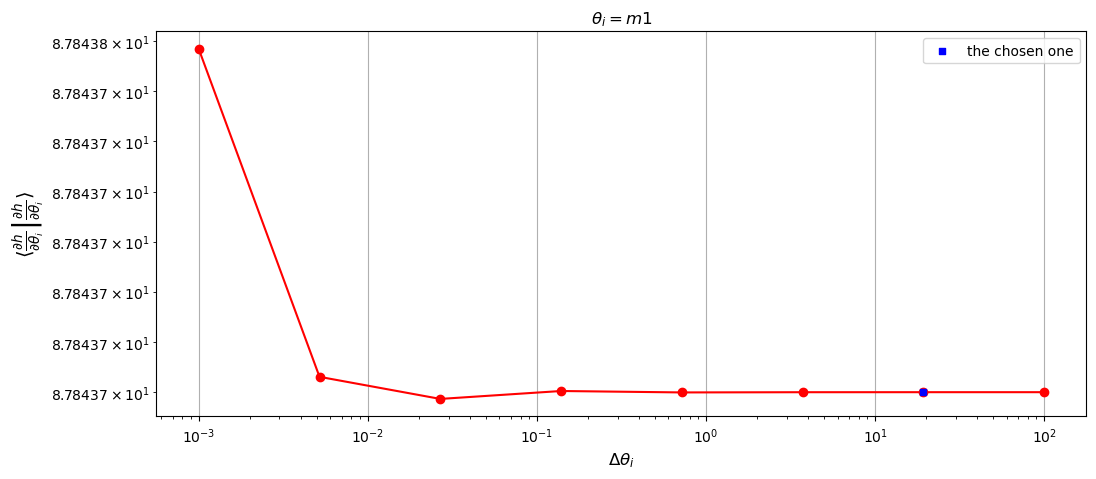

Gamma_ii for m2: 212276655.5685066
Gamma_ii for m2: 212276655.69580504
Gamma_ii for m2: 212276656.2458775
Gamma_ii for m2: 212276651.21564263
Gamma_ii for m2: 212276667.50150254
Gamma_ii for m2: 212276635.9930343
Gamma_ii for m2: 212276107.00619036
Gamma_ii for m2: 212275352.33468175
[np.float64(5.996817883353429e-10), np.float64(2.591299821161264e-09), np.float64(2.3696599906246087e-08), np.float64(7.671997164982167e-08), np.float64(1.4843116432998977e-07), np.float64(2.491975434278007e-06), np.float64(3.5551537204394954e-06)]
0


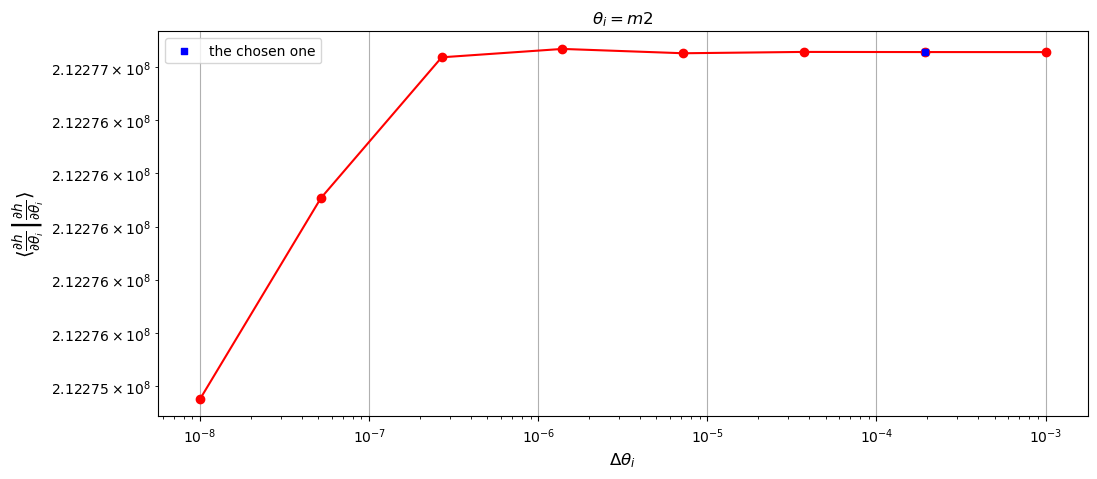

Gamma_ii for p0: 2417930116307.151
Gamma_ii for p0: 2417930912951.6943
Gamma_ii for p0: 2417931399418.587
Gamma_ii for p0: 2417922579613.833
Gamma_ii for p0: 2417921711073.412
Gamma_ii for p0: 2417863442366.445
Gamma_ii for p0: 2413684969537.7144
Gamma_ii for p0: 2411852122771.873
[np.float64(3.294736583207523e-07), np.float64(2.0119135418610318e-07), np.float64(3.647678725641771e-06), np.float64(3.592094884299863e-07), np.float64(2.409925471649284e-05), np.float64(0.0017311591535206679), np.float64(0.0007599333095657913)]
1


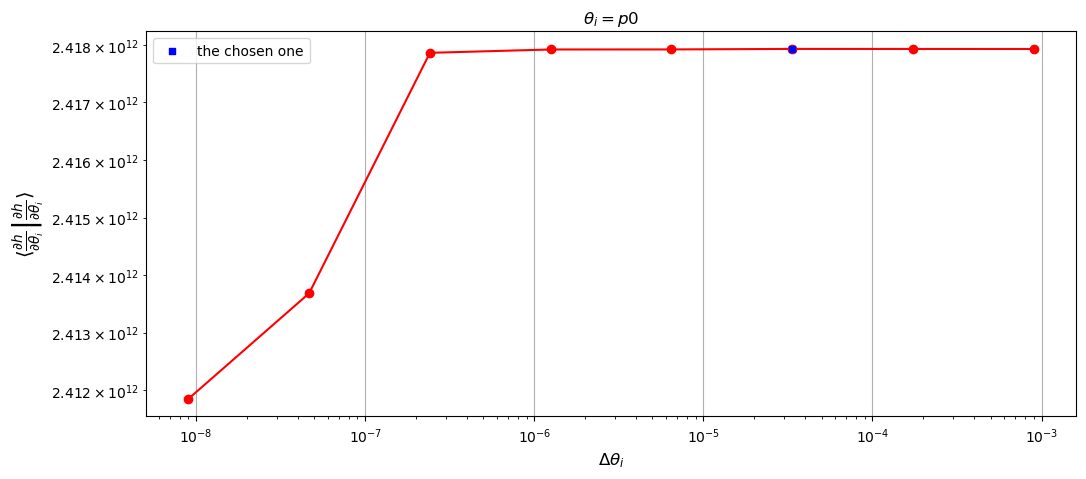

Gamma_ii for e0: 72660504521602.31
Gamma_ii for e0: 72660476573788.5
Gamma_ii for e0: 72660670972432.94
Gamma_ii for e0: 72661608656560.28
Gamma_ii for e0: 72658086018984.11
Gamma_ii for e0: 72602661019479.97
Gamma_ii for e0: 72806738755608.98
Gamma_ii for e0: 71792552366697.19
[np.float64(3.846357074759661e-07), np.float64(2.6754314519233355e-06), np.float64(1.290480825680276e-05), np.float64(4.848238880461949e-05), np.float64(0.0007634017641484185), np.float64(0.002803006144994973), np.float64(0.014126623939090557)]
0


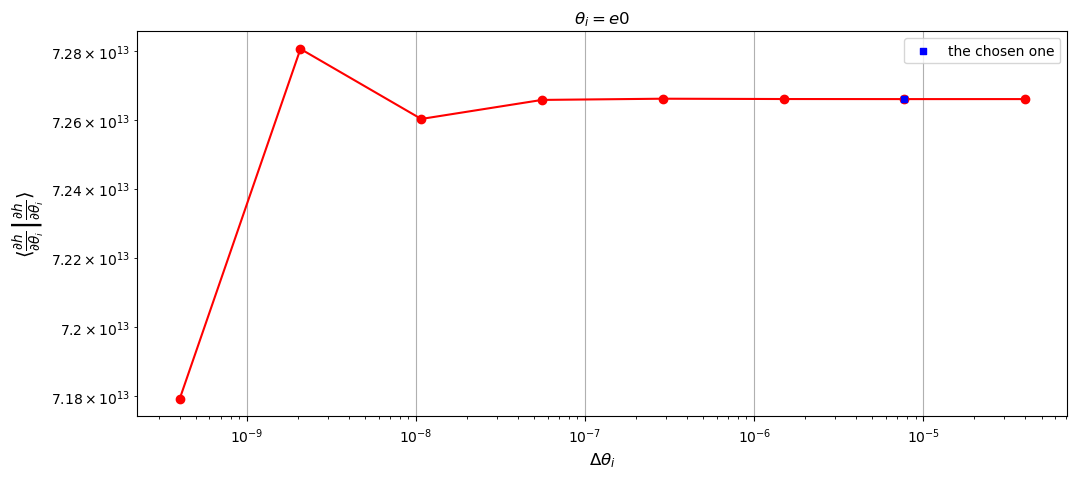

Gamma_ii for qS: 300950.1118665048
Gamma_ii for qS: 300950.1118998417
Gamma_ii for qS: 300950.1118998443
Gamma_ii for qS: 300950.11189984257
Gamma_ii for qS: 300950.11189983186
Gamma_ii for qS: 300950.11189981
Gamma_ii for qS: 300950.11190054676
Gamma_ii for qS: 300950.11189953866
[np.float64(1.1077206773871723e-10), np.float64(8.7035845395457e-15), np.float64(5.8023896930305e-15), np.float64(3.5587990117255e-14), np.float64(7.25298711628891e-14), np.float64(2.44802821148384e-12), np.float64(3.3497195697898904e-12)]
2


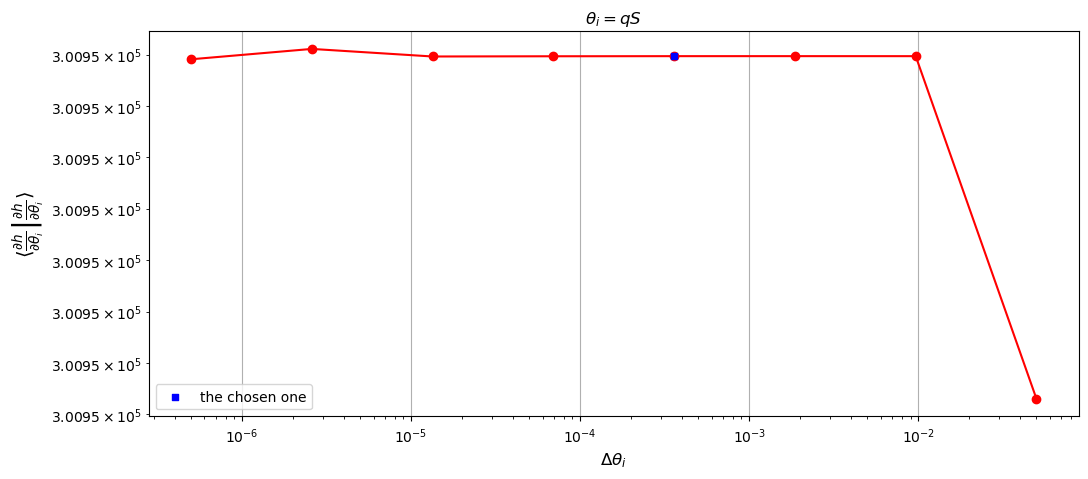

Gamma_ii for phiS: 339787.3832339381
Gamma_ii for phiS: 339787.3904735485
Gamma_ii for phiS: 339787.3904739217
Gamma_ii for phiS: 339787.3904739265
Gamma_ii for phiS: 339787.390474075
Gamma_ii for phiS: 339787.39047426387
Gamma_ii for phiS: 339787.39047680487
Gamma_ii for phiS: 339787.3904887769
[np.float64(2.1306295128589253e-08), np.float64(1.098414868358094e-12), np.float64(1.4047102184242428e-14), np.float64(4.37001922829107e-13), np.float64(5.558883730222124e-13), np.float64(7.478197545679566e-12), np.float64(3.523390101127247e-11)]
2


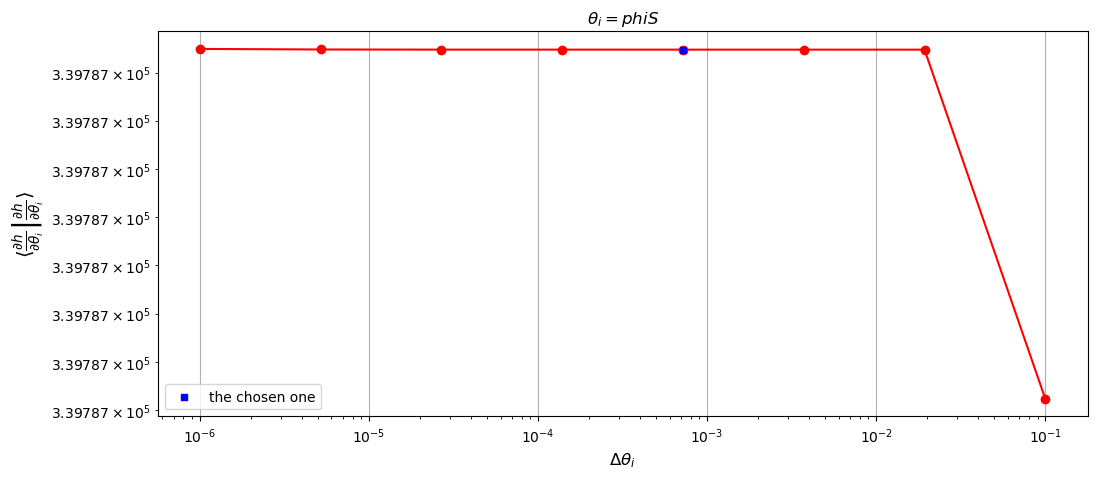

Gamma_ii for qK: 272717.96366015414
Gamma_ii for qK: 272718.00103635277
Gamma_ii for qK: 272718.0010382949
Gamma_ii for qK: 272718.0010383105
Gamma_ii for qK: 272718.0010387848
Gamma_ii for qK: 272718.00103937957
Gamma_ii for qK: 272718.0010475134
Gamma_ii for qK: 272718.0010855936
[np.float64(1.3705072083454754e-07), np.float64(7.1214837548110244e-12), np.float64(5.720067272940254e-14), np.float64(1.7390711992476173e-12), np.float64(2.180882365472926e-12), np.float64(2.982502837907286e-11), np.float64(1.3963217799191272e-10)]
2


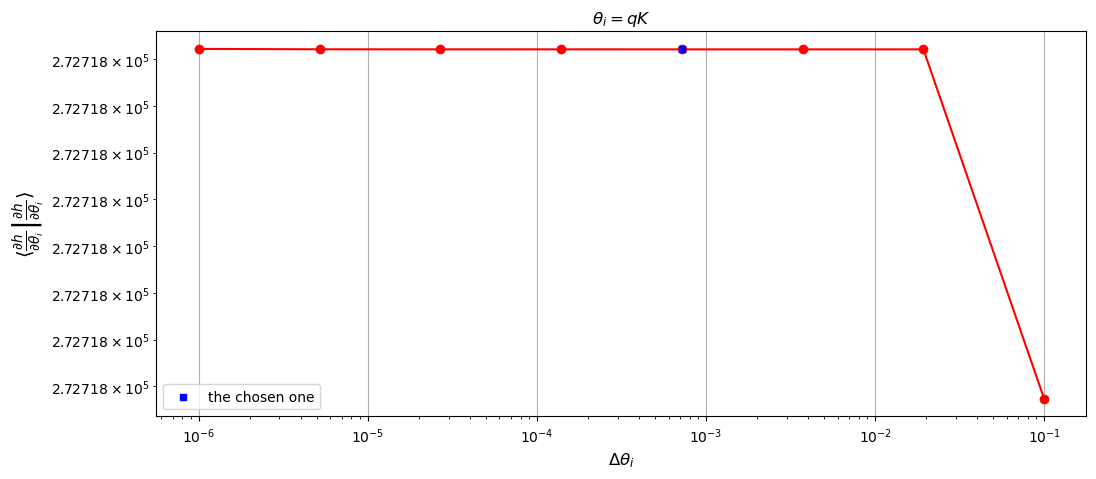

Gamma_ii for chi2: 1.0656550729675074e-17
Gamma_ii for chi2: 2.8588283834684406e-16
Gamma_ii for chi2: 7.669366883757124e-15
Gamma_ii for chi2: 2.0574578291512787e-13
Gamma_ii for chi2: 5.519533467229491e-12
Gamma_ii for chi2: 1.4807229224442256e-10
Gamma_ii for chi2: 3.972329158015434e-09
Gamma_ii for chi2: 1.0656550729675075e-07
[np.float64(0.9627240627968505), np.float64(0.9627240627968507), np.float64(0.9627240627968506), np.float64(0.9627240627968506), np.float64(0.9627240627968505), np.float64(0.9627240627968507), np.float64(0.9627240627968506)]
0
minimum relative error is greater than 1% for chi2. Fisher may be unstable!


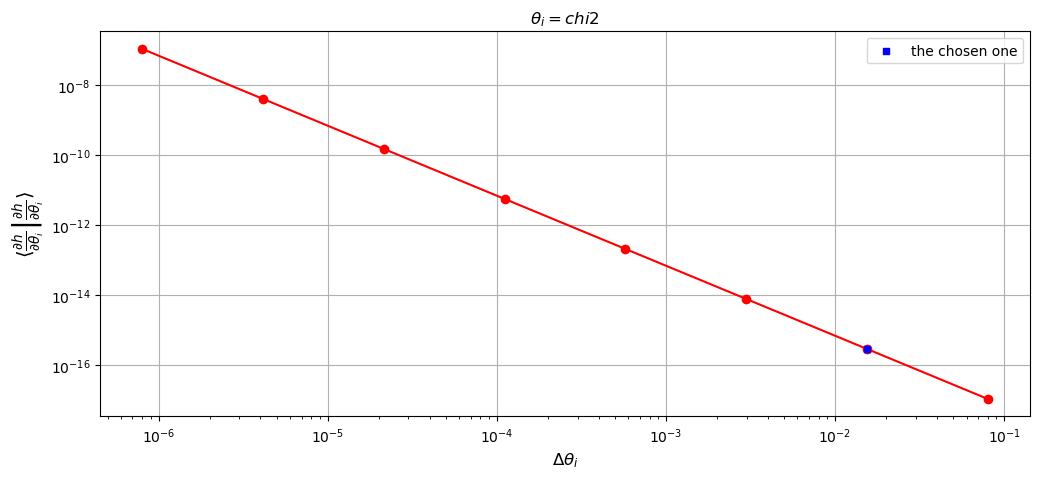

stable deltas: {'m1': 19.306977288832496, 'm2': 0.00019306977288832496, 'p0': 3.3548343482834465e-05, 'e0': 7.722790915533e-06, 'dist': 0.0, 'qS': 0.00035984283650057603, 'phiS': 0.0007196856730011522, 'qK': 0.0007196856730011522, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'chi2': 0.015445581831066002}
Time taken to compute stable deltas is 86.47091913223267 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is not positive semi-definite. Try lowering inspiral error tolerance or increasing the derivative order.
Time taken to compute FM is 14.988402128219604 seconds


In [34]:
der_order = 6
Ndelta = 8
stability_plot = True

delta_range = dict(
    m1 = np.geomspace(1e-4*m1, 1e-9*m1, Ndelta),
    m2 = np.geomspace(1e-2*m2, 1e-7*m2, Ndelta),
    p0 = np.geomspace(1e-2*p0, 1e-7*p0, Ndelta),
    e0 = np.geomspace(1e-1*e0, 1e-7*e0, Ndelta),
    qS = np.geomspace(1e-4,    1e-9,    Ndelta),
    phiS = np.geomspace(1e-4,    1e-9,    Ndelta),
    # qK = np.geomspace(1e-4,    1e-9,    Ndelta),
    phiK = np.geomspace(1e-4,    1e-9,    Ndelta),
)

Fisher = sef(*pars_list,param_names = param_names,T = T, dt = dt, add_param_args=add_param_args,\
             der_order = der_order, Ndelta = Ndelta, stability_plot = stability_plot,
          #   delta_range = delta_range,
            live_dangerously = False)

IndexError: list index out of range

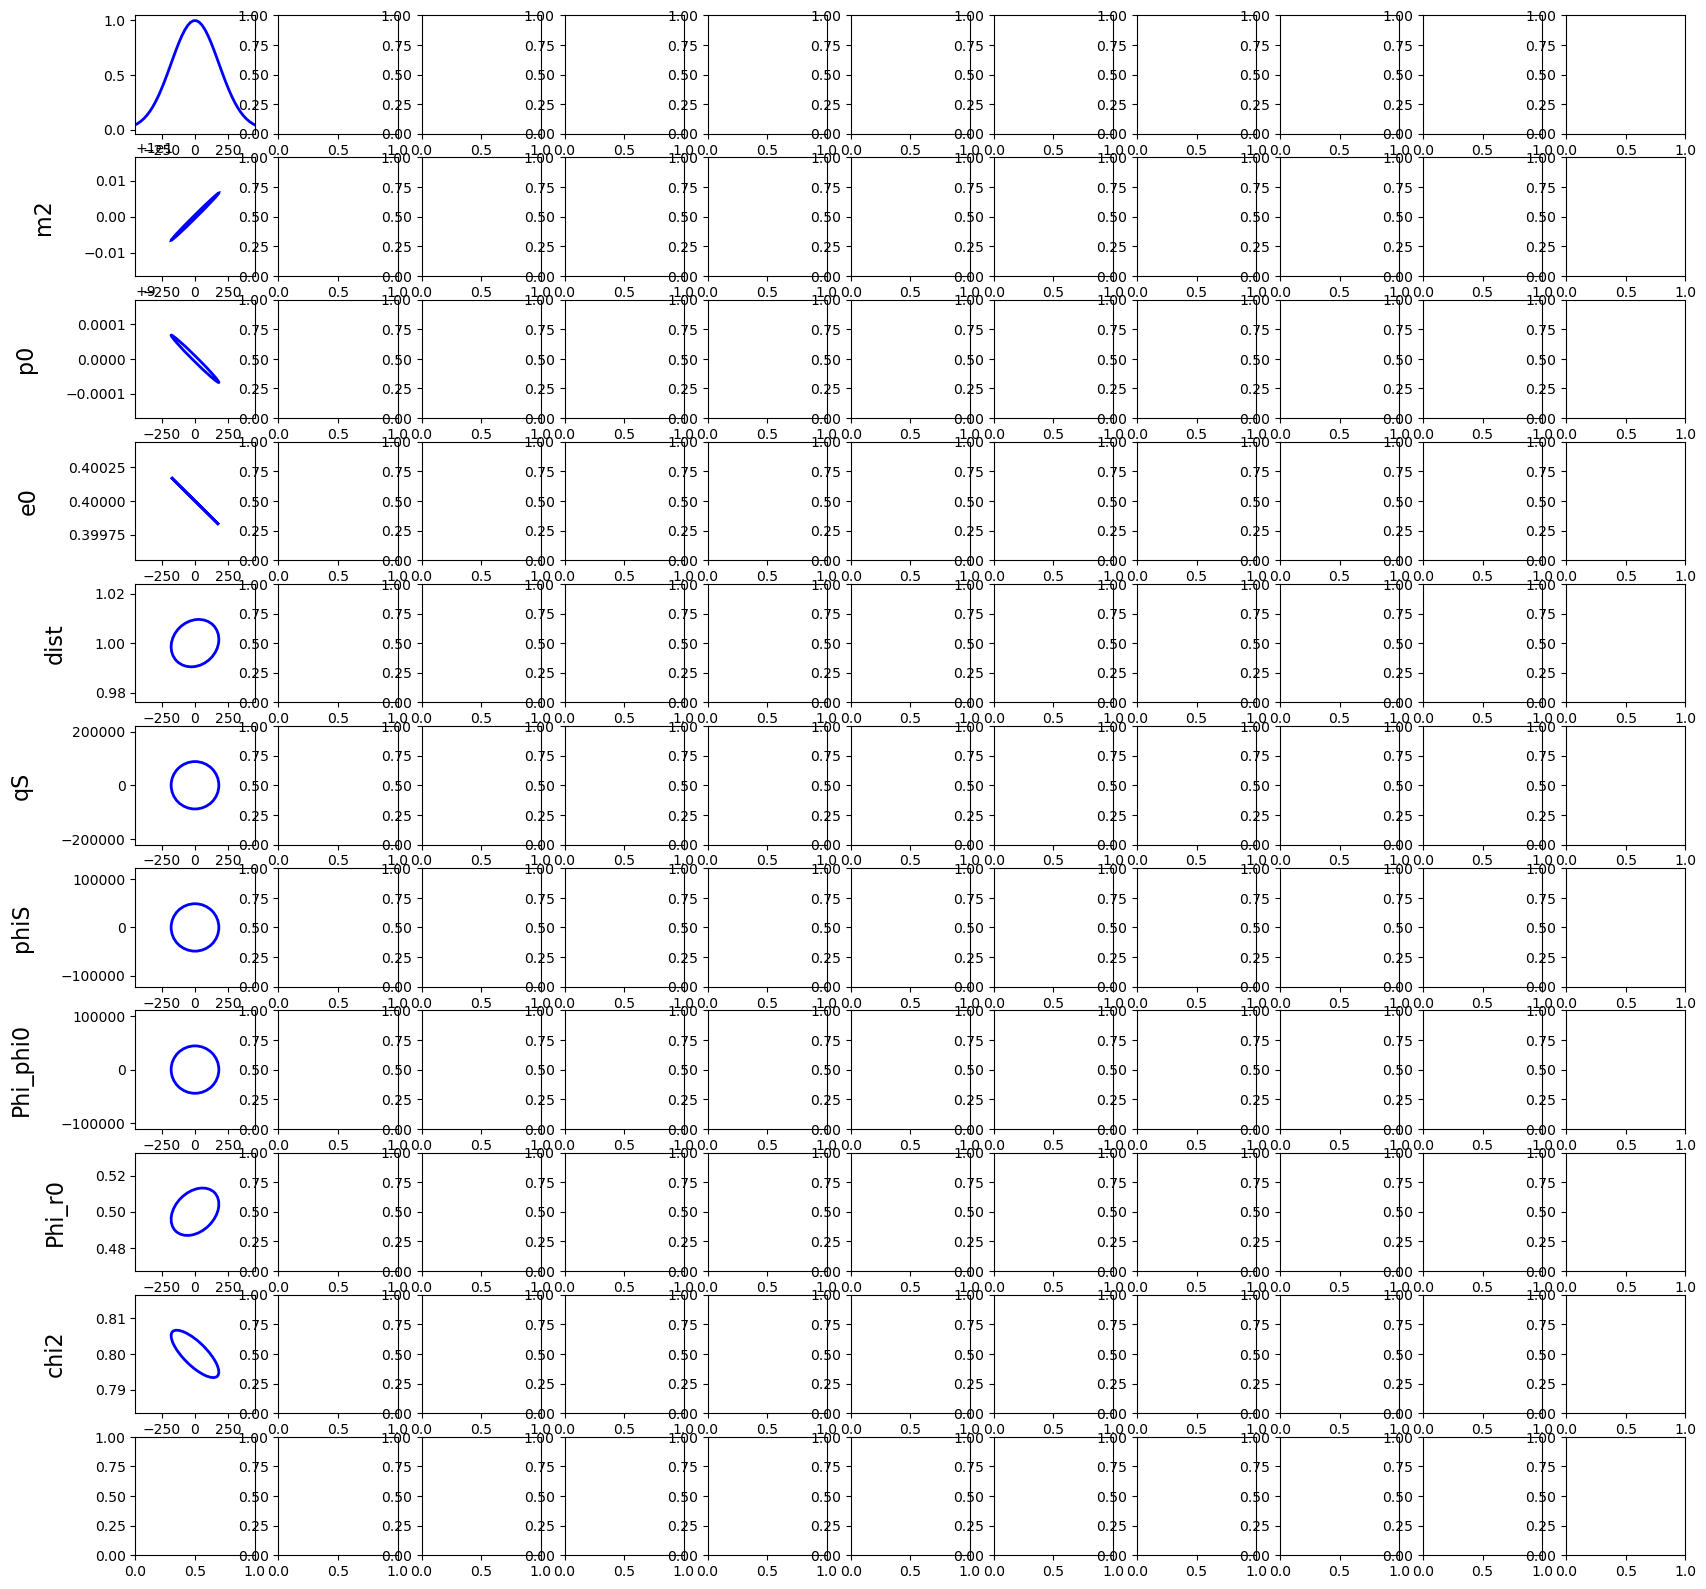

In [35]:

from stableemrifisher.plot import CovEllipsePlot
pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
#param_names = ['m1','m2','p0','e0','dist','qS','phiS','phiK','Phi_phi0','Phi_r0','chi2']

wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = pars_list[i]
    
param_names = param_names

covariance = np.linalg.inv(Fisher)

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)

